## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [4]:
import requests
import pandas as pd

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url =  (
    f"https://api.open-meteo.com/v1/forecast"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    f"&hourly=temperature_2m"
    f"&forecast_days=7"
)

r = requests.get(url)
data = r.json()
print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [5]:
temps  = data["hourly"]["temperature_2m"]
horas  = data["hourly"]["time"]

# Opción A: usar la lista directamente (strings ISO)
# Opción B: convertir a DatetimeIndex con pd.date_range
hours = pd.date_range(start=horas[0], periods=len(temps), freq="h")

print(len(temps), "registros")
print(hours[:3])

168 registros
DatetimeIndex(['2026-03-23 00:00:00', '2026-03-23 01:00:00',
               '2026-03-23 02:00:00'],
              dtype='datetime64[us]', freq='h')


In [6]:
df = pd.DataFrame({
    "Hora"        : hours,
    "Temperatura" : temps
})

df.head()

,Hora,Temperatura
0,2026-03-23 00:00:00,12.3
1,2026-03-23 01:00:00,12.1
2,2026-03-23 02:00:00,11.8
3,2026-03-23 03:00:00,11.5
4,2026-03-23 04:00:00,11.1


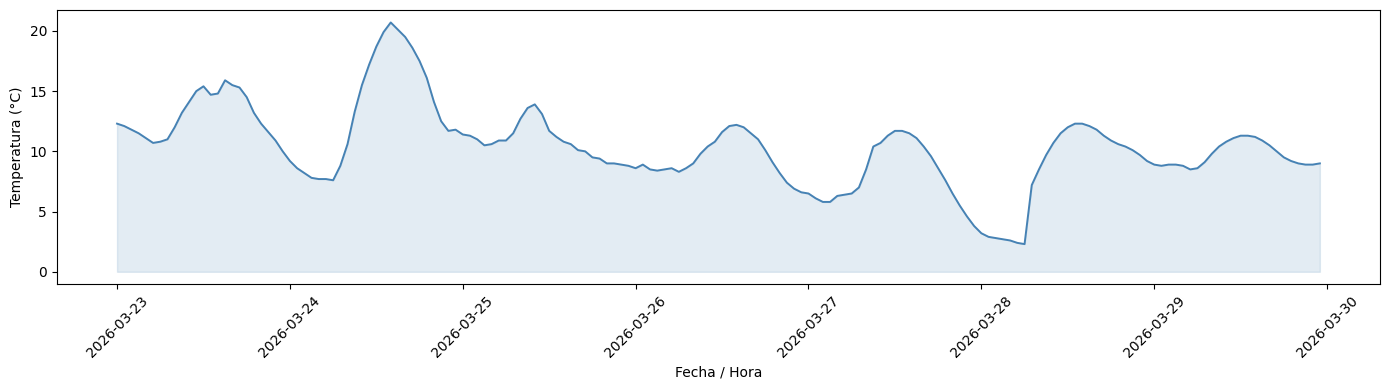

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["Hora"], df["Temperatura"],
       color="steelblue", linewidth=1.4)

ax.fill_between(df["Hora"], df["Temperatura"],
                alpha=0.15, color="steelblue")

ax.set_xlabel("Fecha / Hora")
ax.set_ylabel("Temperatura (°C)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()